In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

y = (65, 156, 100, 134, 16, 108, 121, 4, 39, 143, 56, 26, 22, 1, 1, 5, 65); y = np.array(y)
x = (3.36, 2.88, 3.63, 3.41, 3.78, 4.02, 4.00, 4.23, 3.73, 3.85, 3.97, 4.51,
       4.54, 5.00, 5.00, 4.72, 5.00) ; x = np.array(x)


# a) Plot the data


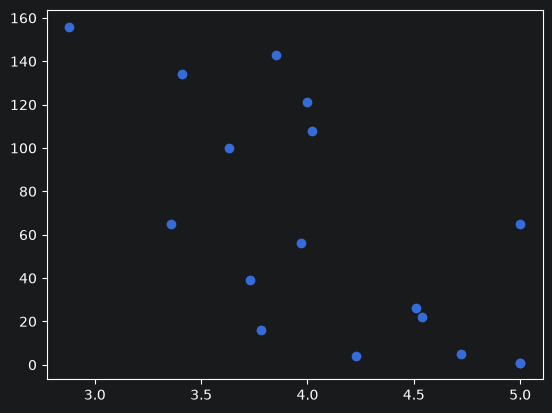

In [34]:
plt.scatter(x, y)
plt.show()

# b)
If we specify a linear predictor
$$ \eta_i = \beta_0 + \beta_1 x_i $$, and $\mu_i = E[y_i] = \exp(\eta_i)$, then it follows that the canonical link function is $$g(\mu_i) = \log(\mu_i) = \eta_i$$.

# c) Fit a GLM with a Gamma family and log link function to the data.

In [35]:
link_func = sm.families.links.Log()
family = sm.families.Gamma(link=link_func)
X = sm.add_constant(x)
model = sm.GLM(y, X, family=family)
result = model.fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                   17
Model:                            GLM   Df Residuals:                       15
Model Family:                   Gamma   Df Model:                            1
Link Function:                    Log   Scale:                         0.93886
Method:                          IRLS   Log-Likelihood:                -83.894
Date:                Sun, 27 Sep 2026   Deviance:                       19.457
Time:                        14:16:58   Pearson chi2:                     14.1
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3480
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.4775      1.603      5.287      0.000       5.335      11.620
x1            -1.1093      0.387     -2.865      0.004      -1.868      -0.350
==============================================================================
"""

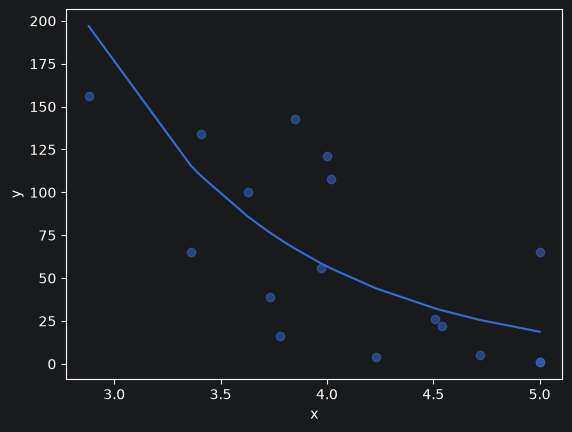

In [36]:
fitted = result.fittedvalues
plt.scatter(x, y, alpha=0.5)

# Sort x and fitted values together
order = x.argsort()

plt.plot(x[order], fitted[order])

plt.xlabel("x")
plt.ylabel("y")
plt.show()

# d) Plot the standardized residuals against the fitted values

We can use the estimated mean as the standardization, since for exponentially distributed RV's
$$Var(Y) = E[Y]^2$$
So the mean is a estimator of the standard deviation. The standardized residuals are then given by
$$r_i = \frac{y_i - \hat{\mu}_i}{\hat{\mu}_i}$$

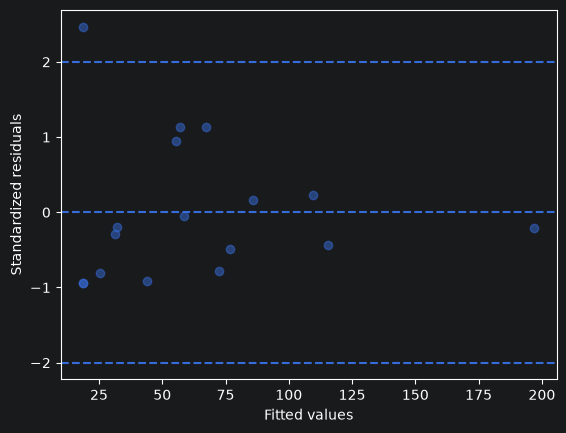

In [37]:
residual = result.resid_response / fitted

plt.scatter(fitted, residual, alpha=0.5)

plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.xlabel("Fitted values")
plt.ylabel("Standardized residuals")
plt.show()